#  Install dependencies

In [2]:
!pip install folium matplotlib pandas

# Imports 

In [3]:
import pandas as pd
import folium
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display, IFrame

# Load data

In [4]:
df = pd.read_csv("AB_NYC_2019.csv")
df = df[(df['price'] > 0) & (df['price'] <= 500)].dropna(subset=['latitude','longitude'])
print(f"Loaded {len(df):,} listings")
print(df[['neighbourhood_group','price','room_type']].describe(include='all').iloc[:3])

Loaded 47,840 listings
       neighbourhood_group    price        room_type
count                47840  47840.0            47840
unique                   5      NaN                3
top              Manhattan      NaN  Entire home/apt


# Build interactive Folium map

In [20]:
sample = df.sample(800, random_state=42)
 
def price_color(p):
    if p < 75:   return 'green'
    if p < 150:  return 'beige'
    if p < 300:  return 'orange'
    return 'red'
 
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11,
               tiles='CartoDB dark_matter')
 
for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='black',
        weight=0.5,
        fill=True,
        fill_color=price_color(row['price']),
        fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{str(row['name'])[:40]}</b><br>"
            f"Borough: {row['neighbourhood_group']}<br>"
            f"Type: {row['room_type']}<br>"
            f"Price: <b>${row['price']:.0f}/night</b>",
            max_width=220
        )
    ).add_to(m)
 
# Colour legend
legend_html = """
<div style="position:fixed;bottom:40px;left:40px;z-index:1000;
     background:#1e2440;padding:14px 18px;border-radius:10px;
     border:1px solid #252d50;font-family:Arial;font-size:12px;color:#e0e0e0">
  <b style="color:#fff">Price / night</b><br><br>
  <span style="color:#2ecc71">●</span> Under $75<br>
  <span style="color:#f1c40f">●</span> $75 – $150<br>
  <span style="color:#e67e22">●</span> $150 – $300<br>
  <span style="color:#e74c3c">●</span> Over $300
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))
 
m.save("nyc_airbnb_map.html")
print("Map saved → nyc_airbnb_map.html")
display(IFrame("nyc_airbnb_map.html", width="100%", height="520px"))

Map saved → nyc_airbnb_map.html


# Chart styling

In [10]:
DARK = "#0f1117"; CARD = "#1e2440"; TEXT = "#e0e0e0"; GRID = "#252d50"
BC   = {"Manhattan":"#e74c3c","Brooklyn":"#3498db","Queens":"#2ecc71",
        "Bronx":"#f39c12","Staten Island":"#9b59b6"}
boroughs = list(BC.keys()); colors = list(BC.values())
 
plt.rcParams.update({
    "figure.facecolor": DARK, "axes.facecolor": CARD,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": GRID,
    "font.family": "DejaVu Sans", "font.size": 10,
})

# Avg Price by Borough

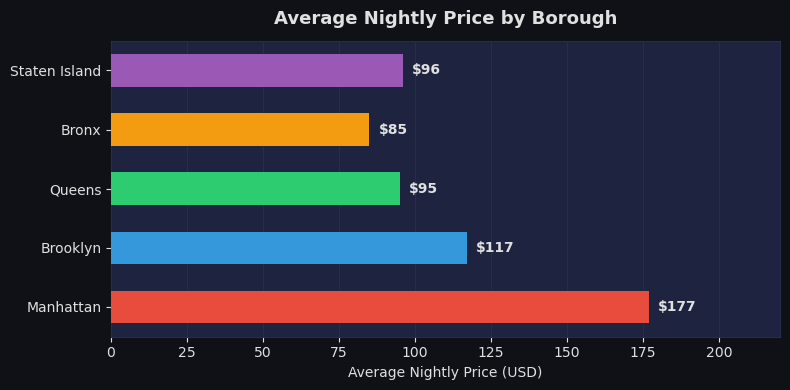

Saved → chart1_price_borough.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor=DARK)
ax.set_facecolor(CARD)
avg_prices = [177, 117, 95, 85, 96]
bars = ax.barh(boroughs, avg_prices, color=colors, height=0.55, zorder=3)
ax.set_xlabel("Average Nightly Price (USD)", color=TEXT, fontsize=10)
ax.set_title("Average Nightly Price by Borough", color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="x", color=GRID, zorder=0); ax.set_xlim(0, 220)
for bar, val in zip(bars, avg_prices):
    ax.text(val+3, bar.get_y()+bar.get_height()/2, f"${val}",
            va="center", color=TEXT, fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("chart1_price_borough.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → chart1_price_borough.png")

# Room Type Donut

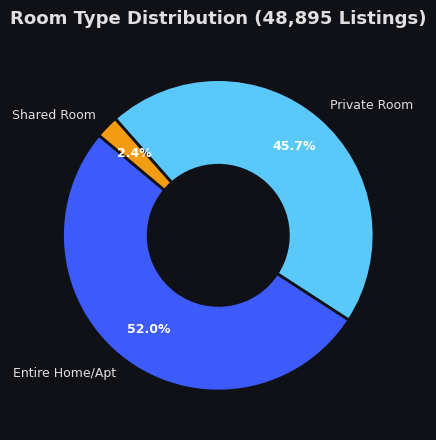

Saved → chart2_room_type.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5), facecolor=DARK)
ax.set_facecolor(DARK)
sizes  = [25409, 22326, 1160]
labels = ["Entire Home/Apt", "Private Room", "Shared Room"]
pie_c  = ["#3d5afa", "#5bc8fa", "#f39c12"]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=pie_c, autopct="%1.1f%%",
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=DARK, linewidth=2))
for t in texts:      t.set_color(TEXT); t.set_fontsize(9)
for t in autotexts:  t.set_color("#fff"); t.set_fontsize(9); t.set_fontweight("bold")
ax.set_title("Room Type Distribution (48,895 Listings)", color=TEXT, fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("chart2_room_type.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → chart2_room_type.png")

# Price Band Distribution

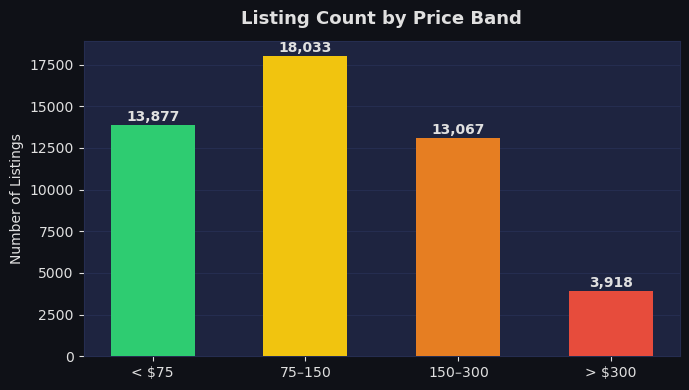

Saved → chart3_price_band.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor=DARK)
ax.set_facecolor(CARD)
bands  = ["< $75", "$75–$150", "$150–$300", "> $300"]
counts = [13877, 18033, 13067, 3918]
band_c = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
bars   = ax.bar(bands, counts, color=band_c, width=0.55, zorder=3)
ax.set_ylabel("Number of Listings", color=TEXT, fontsize=10)
ax.set_title("Listing Count by Price Band", color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="y", color=GRID, zorder=0)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, val+250, f"{val:,}",
            ha="center", color=TEXT, fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("chart3_price_band.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → chart3_price_band.png")

# Availability vs Listing Count

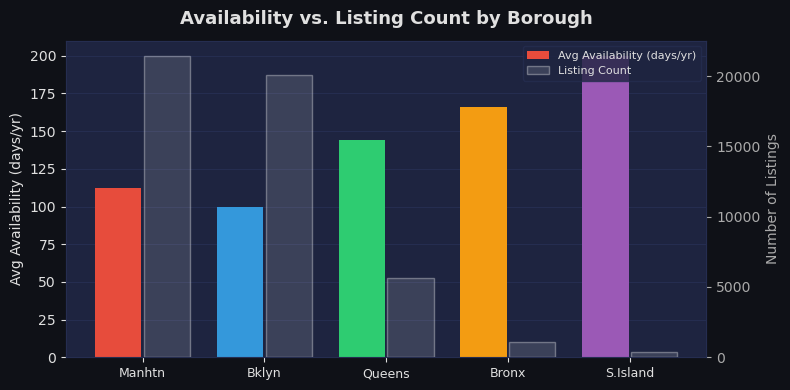

Saved → chart4_availability.png


In [14]:
fig, ax1 = plt.subplots(figsize=(8, 4), facecolor=DARK)
ax1.set_facecolor(CARD)
x = np.arange(len(boroughs))
ax1.bar(x-0.2, [112, 100, 144, 166, 200], 0.38, color=colors, zorder=3,
        label="Avg Availability (days/yr)")
ax1.set_ylabel("Avg Availability (days/yr)", color=TEXT, fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(["Manhtn", "Bklyn", "Queens", "Bronx", "S.Island"], fontsize=9)
ax1.set_title("Availability vs. Listing Count by Borough",
              color=TEXT, fontsize=13, fontweight="bold", pad=12)
ax1.grid(axis="y", color=GRID, zorder=0)
ax2 = ax1.twinx(); ax2.set_facecolor(CARD)
ax2.bar(x+0.2, [21447, 20104, 5666, 1091, 373], 0.38,
        color="#ffffff22", edgecolor="#ffffff55", zorder=3, label="Listing Count")
ax2.set_ylabel("Number of Listings", color="#aaa", fontsize=10)
ax2.tick_params(colors="#aaa")
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc="upper right", fontsize=8,
           facecolor=CARD, edgecolor=GRID, labelcolor=TEXT)
plt.tight_layout()
plt.savefig("chart4_availability.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → chart4_availability.png")

In [15]:
print("\n✅ All files generated:")
print("   nyc_airbnb_map.html      ← interactive map (open in browser)")
print("   chart1_price_borough.png ← Figure 1")
print("   chart2_room_type.png     ← Figure 2")
print("   chart3_price_band.png    ← Figure 3")
print("   chart4_availability.png  ← Figure 4")
print("\nInsert the 4 PNG files into your Word report as images.")


✅ All files generated:
   nyc_airbnb_map.html      ← interactive map (open in browser)
   chart1_price_borough.png ← Figure 1
   chart2_room_type.png     ← Figure 2
   chart3_price_band.png    ← Figure 3
   chart4_availability.png  ← Figure 4

Insert the 4 PNG files into your Word report as images.
